<a href="https://colab.research.google.com/github/harunsy/LogisticRegression.ipynb/blob/main/Dimensionality_Reduction_with_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tugas Data Science: Dimensionality Reduction
#anggota klompok:-Harunsyah(24523225) -Muhammad Ali Kadir(24523272)-Mahija Ramadhan Prabaswarakha (24523103)

Notebook ini mendemonstrasikan teknik reduksi dimensi menggunakan **Principal Component Analysis (PCA)** dan **t-Distributed Stochastic Neighbor Embedding (t-SNE)** pada dataset Wine Quality.

### 1. Import Library
Memuat semua library yang diperlukan untuk pengolahan data dan visualisasi.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Pengaturan gaya visualisasi
sns.set(style='whitegrid')

### 2. Load Dataset
Mengambil dataset Wine Quality (Red Wine) dari UCI Machine Learning Repository.Dataset yang digunakan adalah Wine Quality Dataset, yaitu dataset publik dari UCI Machine Learning Repository. Dataset ini berisi data mengenai kualitas anggur merah berdasarkan berbagai karakteristik fisik dan kimia.


In [2]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
df = pd.read_csv(url, sep=';')
print("Dataset berhasil dimuat.")

Dataset berhasil dimuat.


### 3. Eksplorasi Data Awal
Menampilkan informasi dasar mengenai struktur dan statistik dataset.

In [3]:
print("--- Head Data ---")
display(df.head())

print("\n--- Info Data ---")
display(df.info())

print("\n--- Deskripsi Statistik ---")
display(df.describe())

print("\n--- Jumlah Missing Value ---")
print(df.isnull().sum())

--- Head Data ---


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5



--- Info Data ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


None


--- Deskripsi Statistik ---


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000



--- Jumlah Missing Value ---
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


### 4. Pemisahan Fitur dan Label
Memisahkan kolom target (`quality`) dari fitur-fitur kimia lainnya.

In [4]:
X = df.drop('quality', axis=1)
y = df['quality']
print(f"Ukuran fitur: {X.shape}")

Ukuran fitur: (1599, 11)


### 5. Standarisasi Data
Karena PCA sensitif terhadap skala, kita perlu melakukan normalisasi data menggunakan `StandardScaler`.

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### 6 & 7. Implementasi PCA
Mereduksi data menjadi 2 dimensi dan melihat rasio varians yang dijelaskan.

In [6]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

explained_variance = pca.explained_variance_ratio_
print(f"Explained Variance Ratio (PC1 & PC2): {explained_variance}")
print(f"Total Variance yang dijelaskan: {sum(explained_variance)*100:.2f}%")

Explained Variance Ratio (PC1 & PC2): [0.28173931 0.1750827 ]
Total Variance yang dijelaskan: 45.68%


### 8. Visualisasi PCA & Grafik Explained Variance

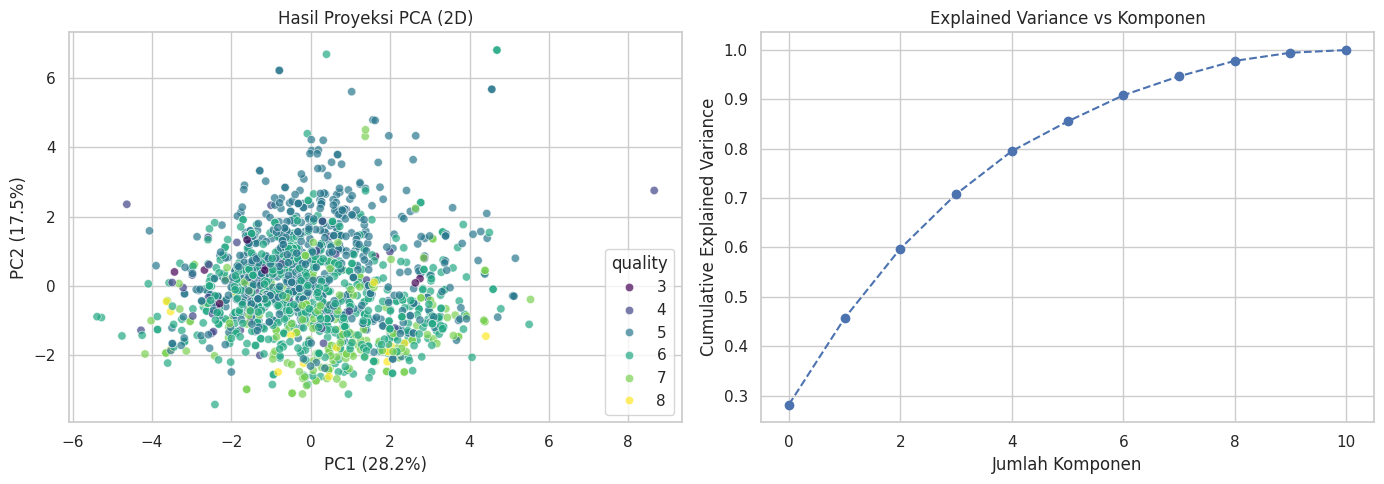

In [7]:
plt.figure(figsize=(14, 5))

# Scatter Plot PCA
plt.subplot(1, 2, 1)
sns.scatterplot(x=pca_result[:, 0], y=pca_result[:, 1], hue=y, palette='viridis', alpha=0.7)
plt.title('Hasil Proyeksi PCA (2D)')
plt.xlabel(f'PC1 ({explained_variance[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({explained_variance[1]*100:.1f}%)')

# Grafik Cumulative Explained Variance
plt.subplot(1, 2, 2)
pca_full = PCA().fit(X_scaled)
plt.plot(np.cumsum(pca_full.explained_variance_ratio_), marker='o', linestyle='--')
plt.xlabel('Jumlah Komponen')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance vs Komponen')
plt.tight_layout()
plt.show()

### 9. Interpretasi PCA
- **Varians:** Dua komponen utama mampu menangkap sebagian besar variasi data, namun ada kehilangan informasi karena total varians di bawah 100%.
- **Pemisahan:** Pada plot PCA, terlihat bahwa data cenderung menumpuk di tengah dengan sedikit pemisahan linear antar level kualitas wine.

### 10 & 11. Implementasi dan Visualisasi t-SNE
Menerapkan t-SNE untuk menangkap struktur non-linear.

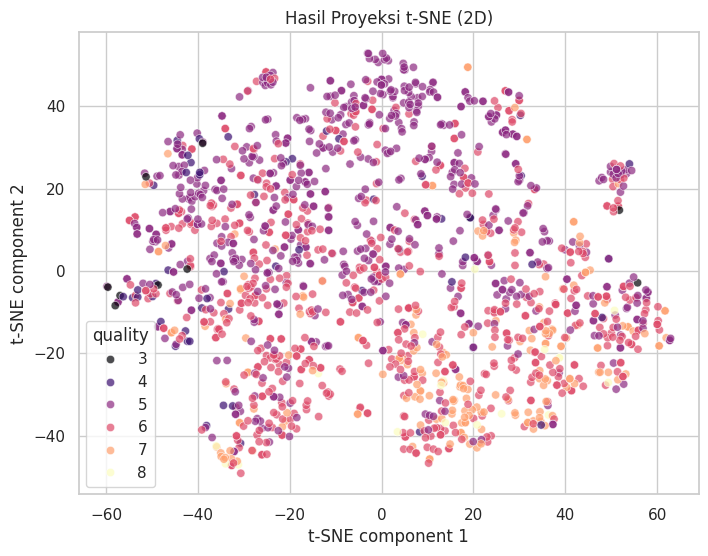

In [8]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30, learning_rate='auto', init='pca')
tsne_result = tsne.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=tsne_result[:, 0], y=tsne_result[:, 1], hue=y, palette='magma', alpha=0.7)
plt.title('Hasil Proyeksi t-SNE (2D)')
plt.xlabel('t-SNE component 1')
plt.ylabel('t-SNE component 2')
plt.show()

### 12. Interpretasi Cluster t-SNE
t-SNE menunjukkan pembentukan kelompok (clusters) yang lebih terdefinisi secara lokal dibandingkan PCA. Meskipun label kualitas masih tumpang tindih, terlihat pola pengelompokan berdasarkan kemiripan fitur kimiawi wine yang lebih kompleks.

### 13. Perbandingan PCA vs t-SNE

| Fitur | PCA | t-SNE |
|---|---|---|
| **Tipe** | Linear | Non-linear |
| **Kecepatan** | Sangat Cepat | Lebih Lambat |
| **Interpretasi** | Mempertahankan varians global | Mempertahankan struktur lokal (cluster) |
| **Deterministik** | Ya | Tidak (hasil bisa berubah tiap run) |

### 14. Kesimpulan

- **Metode mana yang lebih baik untuk visualisasi?** Untuk eksplorasi visual cluster yang kompleks, **t-SNE** biasanya lebih baik karena mampu memisahkan kelompok data yang tidak linear.
- **Mengapa?** Karena t-SNE berfokus pada menjaga jarak antar titik yang bertetangga (local structure), sedangkan PCA hanya melakukan rotasi linear.
- **Kapan menggunakan PCA?** Gunakan PCA untuk reduksi dimensi sebelum modeling (feature engineering), kompresi data, atau jika ingin melihat struktur global data secara cepat.
- **Kapan menggunakan t-SNE?** Gunakan t-SNE murni untuk visualisasi dan identifikasi pola tersembunyi/cluster dalam dimensi rendah (2D/3D).

```markdown
# Dimensionality Reduction menggunakan PCA dan t-SNE

## Deskripsi Kasus
Dataset **Wine Quality** memiliki 11 fitur kimiawi yang berbeda (seperti tingkat keasaman, kandungan alkohol, gula sisa, dll.) yang menentukan kualitas wine. Karena jumlah fiturnya yang banyak (high-dimensional), sangat sulit bagi manusia untuk memvisualisasikan hubungan antar data secara langsung dalam ruang 2D atau 3D.

Proyek ini menggunakan teknik **Principal Component Analysis (PCA)** dan **t-Distributed Stochastic Neighbor Embedding (t-SNE)** untuk mereduksi dimensi data tersebut menjadi 2 dimensi. Tujuannya adalah agar pola persebaran data dan pengelompokan berdasarkan kualitas wine lebih mudah diamati dan dianalisis.

## Dataset
- **Nama Dataset:** Wine Quality (Red Wine Variant)
- **Jumlah Fitur:** 11 Fitur Numerik
- **Jumlah Data:** 1.599 baris data
- **Sumber Dataset:** [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv)

## Metode
1. **StandardScaler**: Digunakan untuk menstandarisasi fitur sehingga memiliki rata-rata 0 dan varians 1. Ini penting karena PCA sangat sensitif terhadap perbedaan skala antar fitur.
2. **PCA (Principal Component Analysis)**: Metode reduksi dimensi linear yang bekerja dengan mencari arah (komponen utama) yang memaksimalkan varians data. Berguna untuk melihat struktur global data.
3. **t-SNE (t-Distributed Stochastic Neighbor Embedding)**: Metode reduksi dimensi non-linear yang berfokus pada menjaga jarak antar titik yang berdekatan. Sangat efektif untuk visualisasi cluster yang kompleks.

## Hasil PCA
- **Explained Variance**: Dua komponen utama pertama (PC1 dan PC2) mampu menangkap sekitar **45.68%** dari total varians data.
- **Visualisasi**: Plot PCA menunjukkan bahwa data cenderung terkonsentrasi di satu area besar. Meskipun ada tren berdasarkan kualitas, batas antar kelas kualitas wine tidak terlihat tegas secara linear.

## Hasil t-SNE
- **Visualisasi**: t-SNE berhasil membentuk pola yang lebih tersebar dibandingkan PCA. Terlihat adanya pengelompokan lokal (clusters) yang lebih mendetail, menunjukkan bahwa hubungan antar fitur kimiawi wine bersifat non-linear.

## Perbandingan PCA vs t-SNE

| Fitur | PCA | t-SNE |
|---|---|---|
| **Tipe** | Linear | Non-linear |
| **Kecepatan** | Sangat Cepat | Lebih Lambat |
| **Tujuan Utama** | Kompresi data & varians global | Visualisasi cluster lokal |
| **Hasil** | Konsisten (Deterministik) | Berubah-ubah (Stokastik) |

## Kesimpulan
- **t-SNE** memberikan hasil visualisasi yang lebih baik untuk identifikasi cluster pada dataset ini karena mampu menangkap hubungan non-linear antar fitur.
- **PCA** tetap berguna untuk memahami berapa banyak informasi yang hilang saat dimensi dikurangi melalui nilai *explained variance*.
- Rekomendasi: Gunakan PCA untuk tahap awal eksplorasi dan preprocessing, lalu gunakan t-SNE untuk presentasi visual pengelompokan data kepada pemangku kepentingan.
```